# Data Load & Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("telcom_data (2).xlsx - Sheet1.csv")

In [3]:
df.head(5)

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,1.311450e+19,4/4/19 12:01,770.0,4/25/19 14:35,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9.16457E+15,...,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,1.311450e+19,4/9/19 13:04,235.0,4/25/19 8:15,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,1.311450e+19,4/9/19 17:42,1.0,4/25/19 11:58,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,1.311450e+19,4/10/19 0:31,486.0,4/25/19 7:36,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,1.311450e+19,4/12/19 20:10,565.0,4/25/19 10:40,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


In [4]:
df.shape

(150001, 55)

In [5]:
df.dtypes

Bearer Id                                   float64
Start                                        object
Start ms                                    float64
End                                          object
End ms                                      float64
Dur. (ms)                                   float64
IMSI                                        float64
MSISDN/Number                               float64
IMEI                                        float64
Last Location Name                           object
Avg RTT DL (ms)                             float64
Avg RTT UL (ms)                             float64
Avg Bearer TP DL (kbps)                     float64
Avg Bearer TP UL (kbps)                     float64
TCP DL Retrans. Vol (Bytes)                 float64
TCP UL Retrans. Vol (Bytes)                 float64
DL TP < 50 Kbps (%)                         float64
50 Kbps < DL TP < 250 Kbps (%)              float64
250 Kbps < DL TP < 1 Mbps (%)               float64
DL TP > 1 Mb

In [6]:
df['Start'] = pd.to_datetime(df['Start'], format='%m/%d/%y %H:%M', errors='coerce')
df['End']   = pd.to_datetime(df['End'],   format='%m/%d/%y %H:%M', errors='coerce')

id_float_cols = ['Bearer Id', 'IMSI', 'MSISDN/Number', 'IMEI']
for col in id_float_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # float64

# ── Helper: float64 → pandas nullable Int64 ───────────────────────────────────
def to_nullable_int64(series):
    """Safely convert a numeric series to pandas nullable Int64."""
    s = pd.to_numeric(series, errors='coerce')
    mask = s.isna().values
    int_vals = np.zeros(len(s), dtype='int64')
    int_vals[~mask] = s.values[~mask].astype('int64')
    return pd.arrays.IntegerArray(int_vals, mask)

# ── 4. Duration / millisecond columns → nullable Int64 ───────────────────────
ms_int_cols = [
    'Start ms', 'End ms',
    'Dur. (ms)', 'Dur. (ms).1',
    'Activity Duration DL (ms)', 'Activity Duration UL (ms)',
]
for col in ms_int_cols:
    df[col] = to_nullable_int64(df[col])

# ── 5. Network-metric float columns ───────────────────────────────────────────
float_cols = [
    'Avg RTT DL (ms)', 'Avg RTT UL (ms)',
    'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)',
    'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)',
    'DL TP < 50 Kbps (%)',        '50 Kbps < DL TP < 250 Kbps (%)',
    '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)',
    'UL TP < 10 Kbps (%)',        '10 Kbps < UL TP < 50 Kbps (%)',
    '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)',
    'HTTP DL (Bytes)', 'HTTP UL (Bytes)',
    'Nb of sec with 125000B < Vol DL',
    'Nb of sec with 1250B < Vol UL < 6250B',
    'Nb of sec with 31250B < Vol DL < 125000B',
    'Nb of sec with 37500B < Vol UL',
    'Nb of sec with 6250B < Vol DL < 31250B',
    'Nb of sec with 6250B < Vol UL < 37500B',
    'Nb of sec with Vol DL < 6250B',
    'Nb of sec with Vol UL < 1250B',
]
for col in float_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('float64')

# ── 6. Byte-volume columns → nullable Int64 ───────────────────────────────────
byte_cols = [
    'Social Media DL (Bytes)', 'Social Media UL (Bytes)',
    'Google DL (Bytes)',       'Google UL (Bytes)',
    'Email DL (Bytes)',        'Email UL (Bytes)',
    'Youtube DL (Bytes)',      'Youtube UL (Bytes)',
    'Netflix DL (Bytes)',      'Netflix UL (Bytes)',
    'Gaming DL (Bytes)',       'Gaming UL (Bytes)',
    'Other DL (Bytes)',        'Other UL (Bytes)',
    'Total UL (Bytes)',        'Total DL (Bytes)',
]
for col in byte_cols:
    df[col] = to_nullable_int64(df[col])

# ── 7. Categorical string columns ─────────────────────────────────────────────
cat_cols = ['Last Location Name', 'Handset Manufacturer', 'Handset Type']
for col in cat_cols:
    df[col] = df[col].astype('category')

# ── 8. Summary ────────────────────────────────────────────────────────────────
print("\n=== Final dtypes ===")
print(df.dtypes.to_string())


=== Final dtypes ===
Bearer Id                                          float64
Start                                       datetime64[ns]
Start ms                                             Int64
End                                         datetime64[ns]
End ms                                               Int64
Dur. (ms)                                            Int64
IMSI                                               float64
MSISDN/Number                                      float64
IMEI                                               float64
Last Location Name                                category
Avg RTT DL (ms)                                    float64
Avg RTT UL (ms)                                    float64
Avg Bearer TP DL (kbps)                            float64
Avg Bearer TP UL (kbps)                            float64
TCP DL Retrans. Vol (Bytes)                        float64
TCP UL Retrans. Vol (Bytes)                        float64
DL TP < 50 Kbps (%)               

In [7]:
df.duplicated().sum()

np.int64(0)

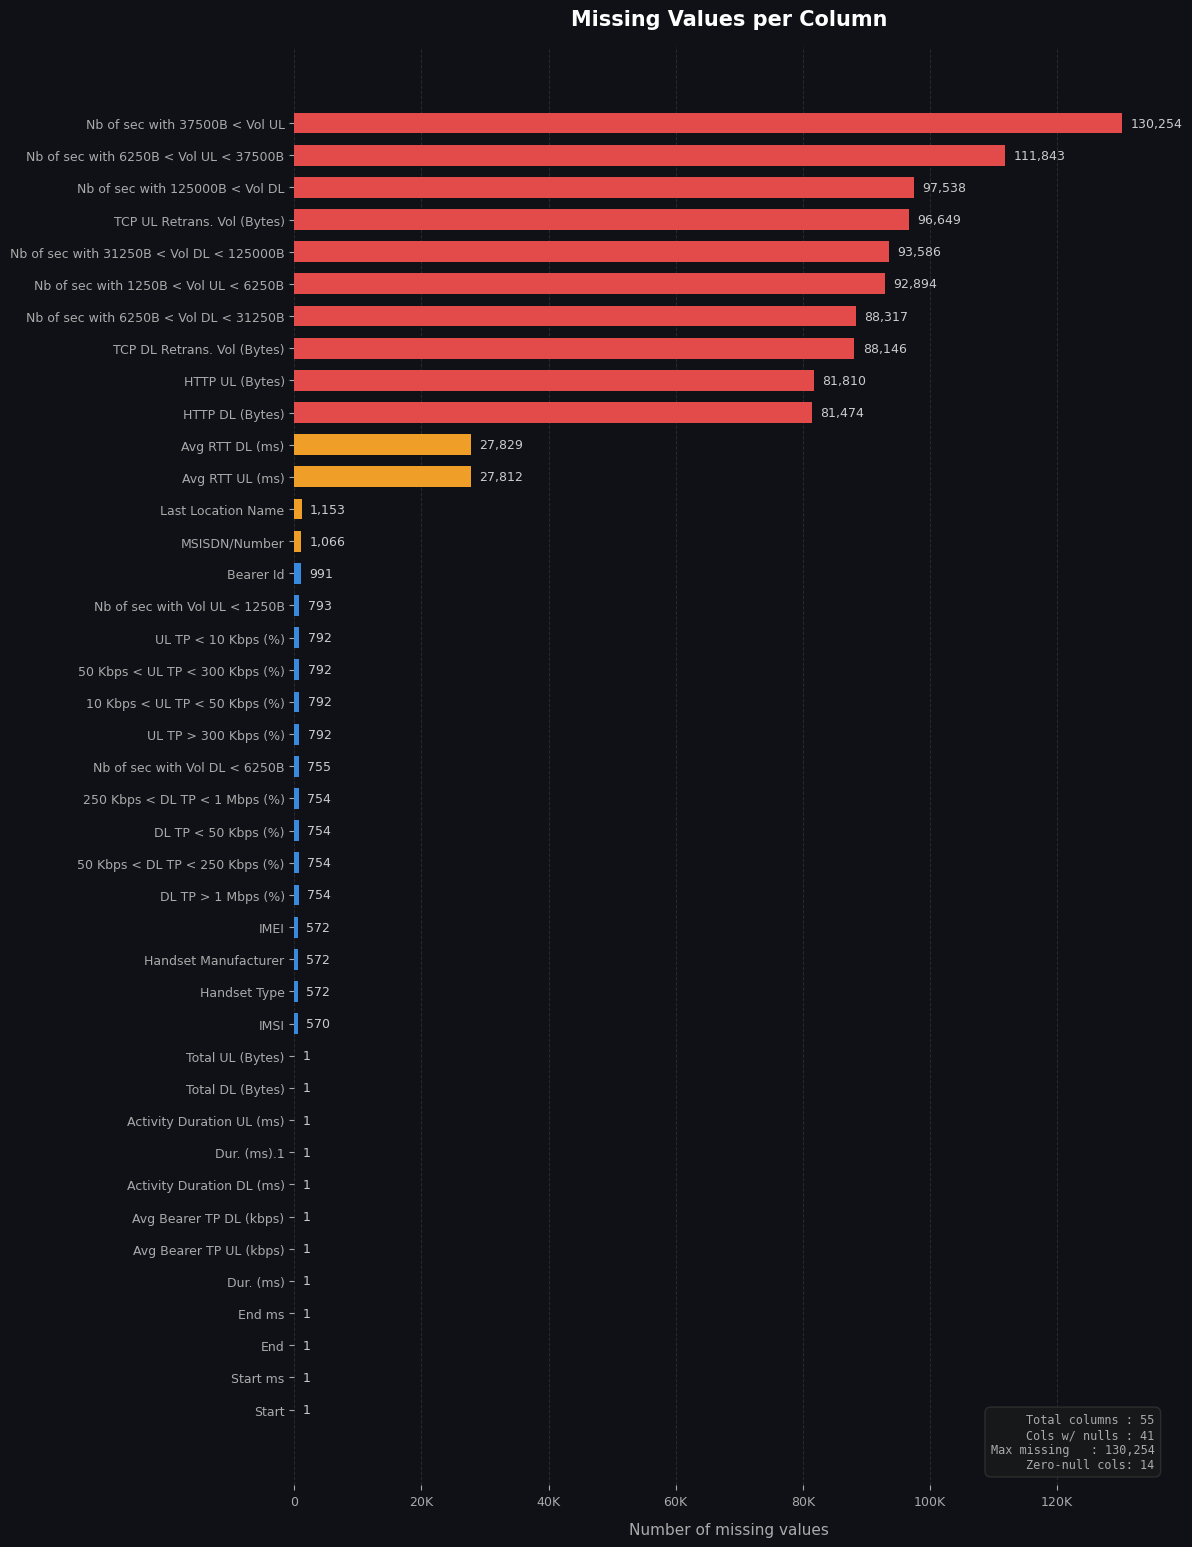

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)   # keep only cols with nulls

def get_color(v):
    if v > 50_000:
        return "#E24B4A"   # red   — high
    elif v >= 1_000:
        return "#EF9F27"   # amber — medium
    else:
        return "#378ADD"   # blue  — low

colors = [get_color(v) for v in missing.values]

fig, ax = plt.subplots(figsize=(12, max(6, len(missing) * 0.38)))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

bars = ax.barh(missing.index, missing.values, color=colors,
               height=0.65, edgecolor="none")

for bar, val in zip(bars, missing.values):
    ax.text(bar.get_width() + missing.values.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", ha="left",
            fontsize=9, color="#cccccc")
    
ax.set_xlabel("Number of missing values", color="#aaaaaa", fontsize=11, labelpad=10)
ax.set_title("Missing Values per Column", color="#ffffff",
             fontsize=15, fontweight="bold", pad=16)

ax.tick_params(colors="#aaaaaa", labelsize=9)
ax.xaxis.set_tick_params(colors="#aaaaaa")
ax.yaxis.set_tick_params(colors="#aaaaaa")

for spine in ax.spines.values():
    spine.set_visible(False)

ax.xaxis.grid(True, color="#2a2a2a", linewidth=0.7, linestyle="--")
ax.set_axisbelow(True)

# X-axis formatter: show K for thousands
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x/1000)}K" if x >= 1000 else str(int(x)))
)

total_cols   = len(df.columns)
cols_w_nulls = len(missing)
max_missing  = int(missing.max())
zero_null    = total_cols - cols_w_nulls

summary = (f"Total columns : {total_cols}\n"
           f"Cols w/ nulls : {cols_w_nulls}\n"
           f"Max missing   : {max_missing:,}\n"
           f"Zero-null cols: {zero_null}")

ax.text(0.99, 0.01, summary, transform=ax.transAxes,
        fontsize=8.5, color="#aaaaaa", va="bottom", ha="right",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#1a1a1a",
                  edgecolor="#333333", alpha=0.8),
        family="monospace")

plt.tight_layout()
plt.show()

In [9]:
# ── Helper: missing audit ──────────────────────────────
def missing_audit(df, label=""):
    m   = df.isnull().sum()
    pct = (m / len(df) * 100).round(2)
    res = pd.DataFrame({'Count': m, 'Pct %': pct})
    res = res[res['Count'] > 0].sort_values('Pct %', ascending=False)
    print(f"\n{'='*52}\n  Missing Values {label}\n{'='*52}")
    print(res.to_string() if not res.empty else "  None ✓")
    print(f"  Columns with missing: {len(res)}")

missing_audit(df, "BEFORE handling")

# ═══════════════════════════════════════════════════════
# STRATEGY 1 — DROP columns with > 50% missing
#   Too sparse to impute reliably; would introduce more
#   noise than signal.
# ═══════════════════════════════════════════════════════
miss_pct  = df.isnull().mean() * 100
drop_cols = miss_pct[miss_pct > 50].index.tolist()

print(f"\n[STRATEGY 1] Dropping {len(drop_cols)} columns (>50% missing):")
for c in drop_cols:
    print(f"   ✗ {c}  ({miss_pct[c]:.1f}%)")

df = df.drop(columns=drop_cols)

# ═══════════════════════════════════════════════════════
# STRATEGY 2 — MEDIAN imputation for RTT columns (~18%)
#   Network latency is right-skewed; median is more
#   representative than mean.
# ═══════════════════════════════════════════════════════
median_cols = [c for c in ['Avg RTT DL (ms)', 'Avg RTT UL (ms)'] if c in df.columns]

print(f"\n[STRATEGY 2] Median imputation ({len(median_cols)} RTT columns):")
for col in median_cols:
    med = df[col].median()
    n   = df[col].isna().sum()
    df[col] = df[col].fillna(med)
    print(f"   ✓ {col}: {n:,} rows filled  (median = {med:.2f})")

# ═══════════════════════════════════════════════════════
# STRATEGY 3 — ZERO FILL for TP % and Nb-of-sec columns
#   Missing = no traffic in that band → 0 is semantically
#   correct, not an approximation.
# ═══════════════════════════════════════════════════════
zero_prefixes = ('DL TP', 'UL TP', '50 Kbps', '250 Kbps', '10 Kbps', 'Nb of sec')
zero_cols = [c for c in df.columns if c.startswith(zero_prefixes)]

print(f"\n[STRATEGY 3] Zero-fill ({len(zero_cols)} TP-distribution / Nb-of-sec columns):")
for col in zero_cols:
    n = df[col].isna().sum()
    if n > 0:
        df[col] = df[col].fillna(0)
        print(f"   ✓ {col}: {n:,} rows filled  → 0")

# ═══════════════════════════════════════════════════════
# STRATEGY 4 — CATEGORICAL: fill with 'Unknown'
# ═══════════════════════════════════════════════════════
cat_cols = ['Last Location Name', 'Handset Manufacturer', 'Handset Type']

print(f"\n[STRATEGY 4] 'Unknown' fill (categorical columns):")
for col in [c for c in cat_cols if c in df.columns]:
    n = df[col].isna().sum()
    if hasattr(df[col], 'cat'):
        # Only add 'Unknown' category if it doesn't already exist
        if 'Unknown' not in df[col].cat.categories:
            df[col] = df[col].cat.add_categories('Unknown')
    df[col] = df[col].fillna('Unknown')
    print(f"   ✓ {col}: {n:,} rows filled  → 'Unknown'")

# ═══════════════════════════════════════════════════════
# STRATEGY 5 — FORWARD FILL for identifier columns
#   Propagates the last known Bearer Id / IMSI / MSISDN /
#   IMEI forward within the session stream.  A trailing
#   bfill covers any leading NaNs at the top of the file.
# ═══════════════════════════════════════════════════════

id_cols = ['Bearer Id', 'IMSI', 'MSISDN/Number', 'IMEI']

print(f"\n[STRATEGY 5] Identifier columns — Forward Fill:")
for col in [c for c in id_cols if c in df.columns]:
    n_before = df[col].isna().sum()
    df[col]  = df[col].ffill().bfill()
    n_after  = df[col].isna().sum()
    print(f"   ✓ {col}: {n_before:,} rows filled  (residual NaN = {n_after})")

# ═══════════════════════════════════════════════════════
# STRATEGY 6 — FORWARD FILL for remaining columns
#   Propagates the last valid observation forward.
#   Suitable for time-ordered session/event data where
#   adjacent rows share context (timestamps, durations,
#   throughput metrics).  A trailing backward fill covers
#   any NaNs left at the very start of the DataFrame.
# ═══════════════════════════════════════════════════════

# Columns already handled by strategies 1-5
already_handled = (
    set(drop_cols)
    | set(median_cols)
    | set(zero_cols)
    | set(c for c in cat_cols  if c in df.columns)
    | set(c for c in id_cols   if c in df.columns)
)

# Identify the 16 residual columns that still have NaNs
residual_missing = [
    c for c in df.columns
    if df[c].isna().any() and c not in already_handled
]

print(f"\n[STRATEGY 6] Forward-fill ({len(residual_missing)} remaining columns):")
for col in residual_missing:
    n_before = df[col].isna().sum()
    df[col]  = df[col].ffill().bfill()        
    n_after  = df[col].isna().sum()
    print(f"   ✓ {col}: {n_before:,} rows filled  (residual NaN = {n_after})")

# ── Final audit ────────────────────────────────────────
missing_audit(df, "AFTER handling")

print(f"\nFinal shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("Done ✓")


  Missing Values BEFORE handling
                                           Count  Pct %
Nb of sec with 37500B < Vol UL            130254  86.84
Nb of sec with 6250B < Vol UL < 37500B    111843  74.56
Nb of sec with 125000B < Vol DL            97538  65.02
TCP UL Retrans. Vol (Bytes)                96649  64.43
Nb of sec with 31250B < Vol DL < 125000B   93586  62.39
Nb of sec with 1250B < Vol UL < 6250B      92894  61.93
Nb of sec with 6250B < Vol DL < 31250B     88317  58.88
TCP DL Retrans. Vol (Bytes)                88146  58.76
HTTP UL (Bytes)                            81810  54.54
HTTP DL (Bytes)                            81474  54.32
Avg RTT DL (ms)                            27829  18.55
Avg RTT UL (ms)                            27812  18.54
Last Location Name                          1153   0.77
MSISDN/Number                               1066   0.71
Bearer Id                                    991   0.66
UL TP < 10 Kbps (%)                          792   0.53
UL TP > 300 Kb

In [10]:
df.to_csv('telecom_cleaned.csv',index=False)

# User Application Behavior Aggregation

In [11]:
# ── Derive combined app traffic columns ─────────────────────────────────────
df['Social Media Total'] = df['Social Media DL (Bytes)'] + df['Social Media UL (Bytes)']
df['Google Total']       = df['Google DL (Bytes)']       + df['Google UL (Bytes)']
df['Email Total']        = df['Email DL (Bytes)']         + df['Email UL (Bytes)']
df['Youtube Total']      = df['Youtube DL (Bytes)']       + df['Youtube UL (Bytes)']
df['Netflix Total']      = df['Netflix DL (Bytes)']       + df['Netflix UL (Bytes)']
df['Gaming Total']       = df['Gaming DL (Bytes)']        + df['Gaming UL (Bytes)']
df['Other Total']        = df['Other DL (Bytes)']         + df['Other UL (Bytes)']
df['Total Traffic']      = df['Total DL (Bytes)']         + df['Total UL (Bytes)']

app_cols = ['Social Media Total','Google Total','Email Total',
            'Youtube Total','Netflix Total','Gaming Total','Other Total']

# Per-user aggregation
user_agg = df.groupby('MSISDN/Number').agg(
    xDR_Sessions     = ('Bearer Id',        'count'),
    Total_Duration   = ('Dur. (ms)',         'sum'),
    Total_DL         = ('Total DL (Bytes)',  'sum'),
    Total_UL         = ('Total UL (Bytes)',  'sum'),
    Total_Traffic    = ('Total Traffic',     'sum'),
    Social_Media     = ('Social Media Total','sum'),
    Google           = ('Google Total',      'sum'),
    Email            = ('Email Total',       'sum'),
    Youtube          = ('Youtube Total',     'sum'),
    Netflix          = ('Netflix Total',     'sum'),
    Gaming           = ('Gaming Total',      'sum'),
    Other            = ('Other Total',       'sum'),
).reset_index()

print(f"Per-user aggregation shape: {user_agg.shape}")
user_agg.head()

Per-user aggregation shape: (106856, 13)


,MSISDN/Number,xDR_Sessions,Total_Duration,Total_DL,Total_UL,Total_Traffic,Social_Media,Google,Email,Youtube,Netflix,Gaming,Other
0,3.360100e+10,1,116720,842637466,36053108,878690574,2232135,4389005,1331362,21624548,27180981,812458661,386570872
1,3.360100e+10,1,181230,120755184,36104459,156859643,2660565,5334863,3307781,12432223,11221763,119750078,281710071
2,3.360100e+10,1,134969,556659663,39306820,595966483,3195623,3443126,3205380,21333570,19353900,538827713,501693672
3,3.360101e+10,1,49878,401993172,20327526,422320698,280294,9678493,2284670,6977321,1942092,391126127,35279702
4,3.360101e+10,2,37104,1363130417,94280527,1457410944,2912542,18499616,3305469,41533002,49201724,1314797820,804804484


# Univariate Anaysis

In [12]:
df = pd.read_csv('telecom_cleaned.csv')

In [13]:
df.describe()

,Bearer Id,Start ms,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
count,1.500010e+05,150001.000000,150001.000000,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,150001.000000,150001.000000,150001.000000,...,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05
mean,1.013837e+19,499.189512,498.799735,1.046085e+05,2.082016e+14,4.182447e+10,4.846465e+13,97.774455,15.315031,13299.957487,...,1.163407e+07,1.100941e+07,1.162685e+07,1.100175e+07,4.220447e+08,8.288398e+06,4.211005e+08,8.264799e+06,4.112113e+07,4.546429e+08
std,2.893198e+18,288.611320,288.097034,8.103735e+04,2.144740e+10,2.438731e+12,2.241194e+13,559.909444,76.687998,23971.823106,...,6.710569e+06,6.345423e+06,6.725218e+06,6.359490e+06,2.439675e+08,4.782700e+06,2.432050e+08,4.769004e+06,1.127639e+07,2.441422e+08
min,6.917540e+18,0.000000,0.000000,7.142000e+03,2.040471e+14,3.360100e+10,4.400152e+11,0.000000,0.000000,0.000000,...,5.300000e+01,1.050000e+02,4.200000e+01,3.500000e+01,2.516000e+03,5.900000e+01,3.290000e+03,1.480000e+02,2.866892e+06,7.114041e+06
25%,7.349880e+18,250.000000,251.000000,5.744200e+04,2.082014e+14,3.365128e+10,3.546071e+13,35.000000,3.000000,43.000000,...,5.833501e+06,5.517965e+06,5.777156e+06,5.475981e+06,2.104733e+08,4.128476e+06,2.101869e+08,4.145943e+06,3.322196e+07,2.431072e+08
50%,7.349880e+18,499.000000,500.000000,8.639900e+04,2.082015e+14,3.366370e+10,3.572201e+13,45.000000,5.000000,63.000000,...,1.161602e+07,1.101345e+07,1.164222e+07,1.099638e+07,4.234081e+08,8.291208e+06,4.218030e+08,8.267071e+06,4.114324e+07,4.558409e+08
75%,1.304240e+19,749.000000,750.000000,1.324300e+05,2.082018e+14,3.368345e+10,8.611970e+13,62.000000,11.000000,19710.000000,...,1.744852e+07,1.651556e+07,1.747048e+07,1.650727e+07,6.331742e+08,1.243162e+07,6.316918e+08,1.238415e+07,4.903424e+07,6.657051e+08
max,1.318650e+19,999.000000,999.000000,1.859336e+06,2.140743e+14,8.823971e+14,9.900120e+13,96923.000000,7120.000000,378160.000000,...,2.325910e+07,2.201196e+07,2.325919e+07,2.201196e+07,8.434419e+08,1.655879e+07,8.434425e+08,1.655882e+07,7.833131e+07,9.029696e+08


In [14]:
warnings.filterwarnings('ignore')

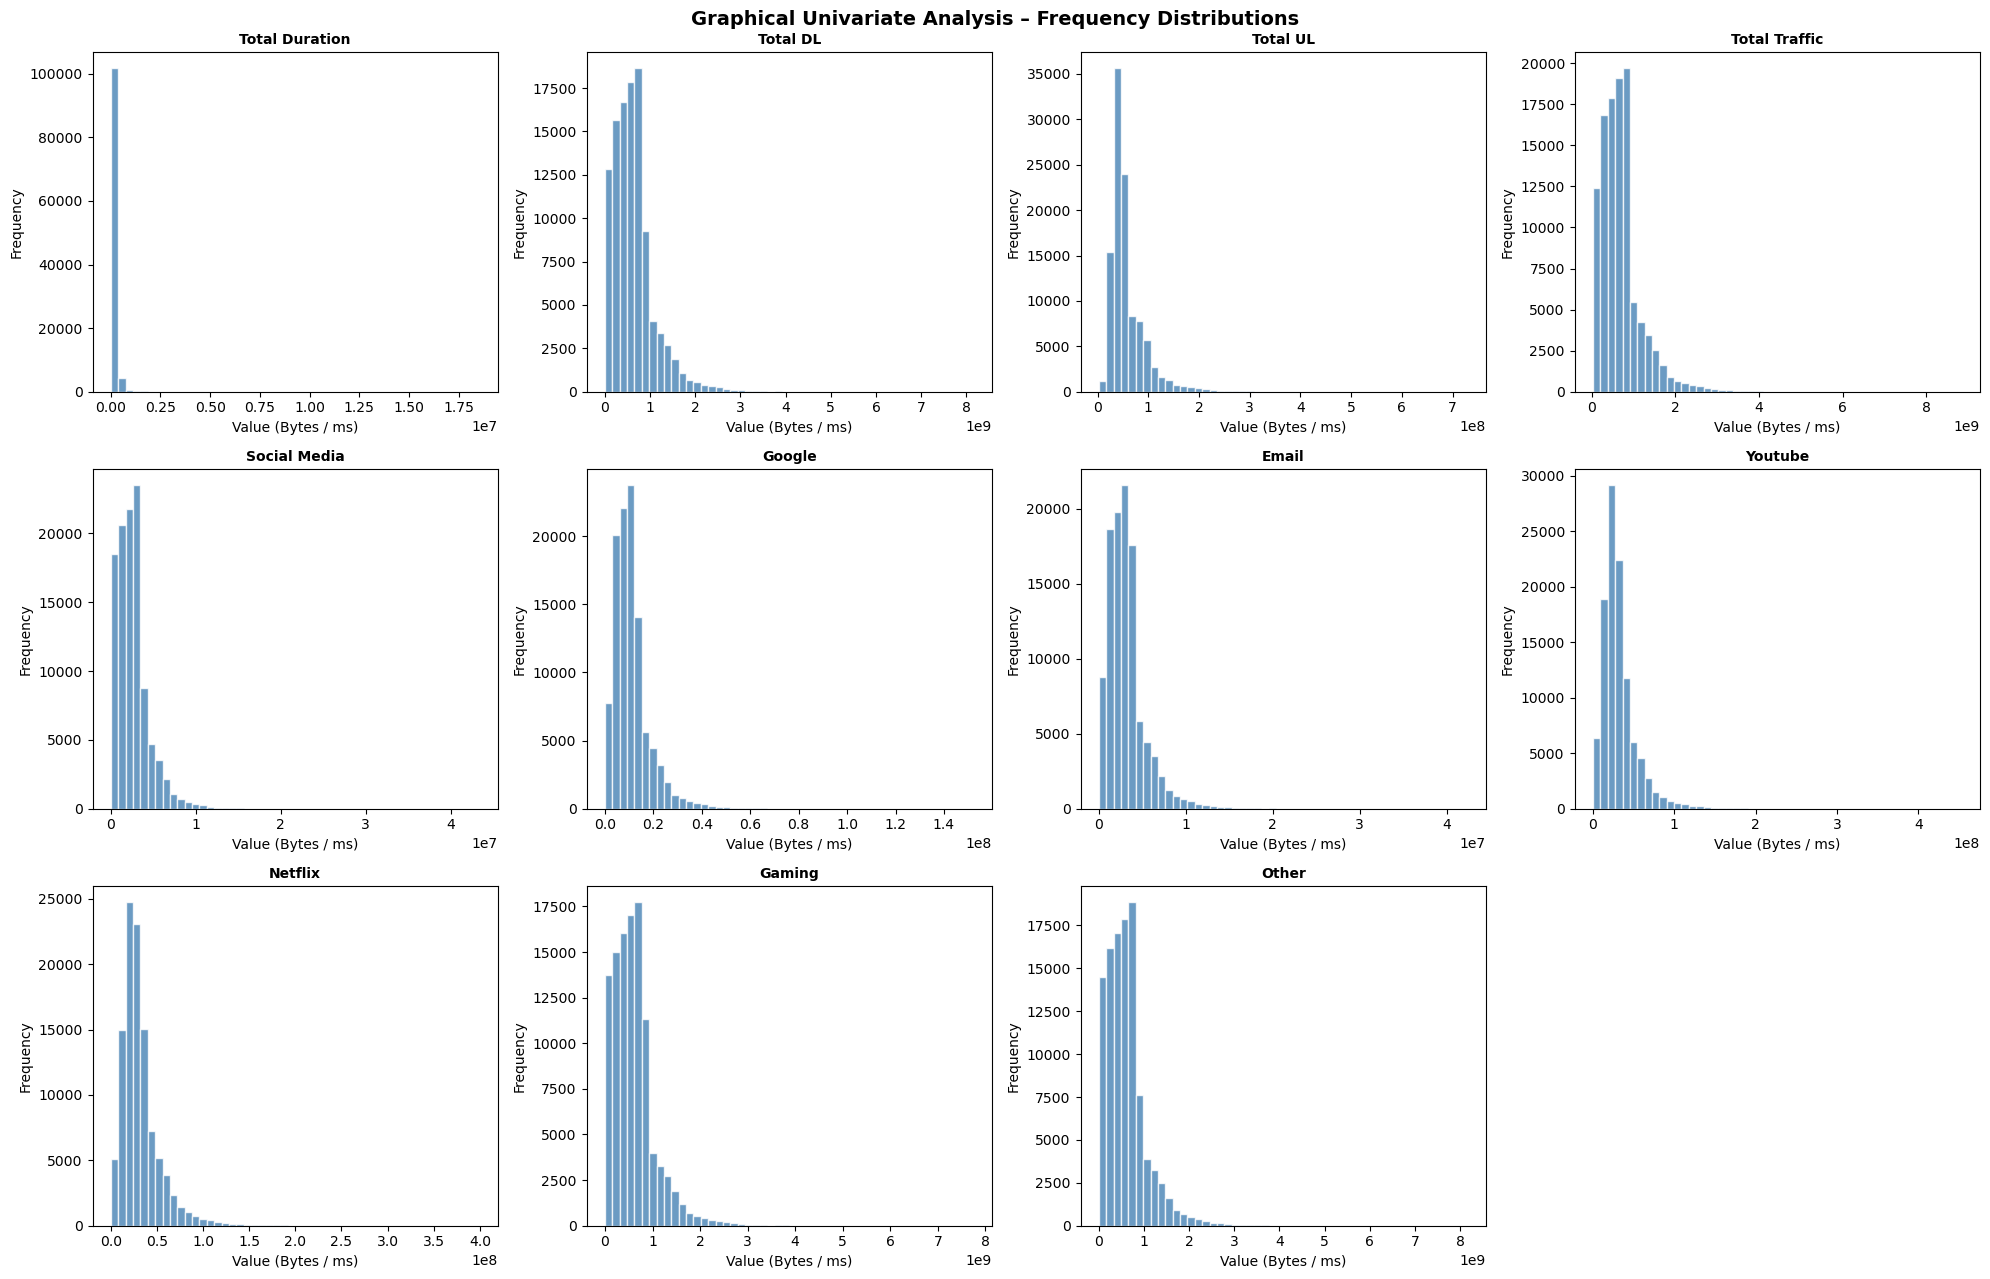

In [15]:
key_cols = ['Total_Duration','Total_DL','Total_UL','Total_Traffic'] + \
           ['Social_Media','Google','Email','Youtube','Netflix','Gaming','Other']

fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    axes[i].hist(user_agg[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col.replace('_',' '), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value (Bytes / ms)')
    axes[i].set_ylabel('Frequency')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Graphical Univariate Analysis – Frequency Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Insights

Content consumption is dominated by media-heavy apps. The data traffic scale for Netflix and Gaming is multi-fold higher than Email or Social Media.

Apps like Social Media and Google have a massive frequency (very tall bars on the left), meaning users open them constantly throughout the day, but they don't consume huge amounts of bytes per session.

The extremely sharp spike in Total Duration near zero proves that your network experiences millions of micro-transactions—users checking notifications for just a few seconds and disconnecting.

Ensure your network switchboards can handle millions of simultaneous connection requests without dropping signal, rather than worrying about long-lasting continuous sessions.

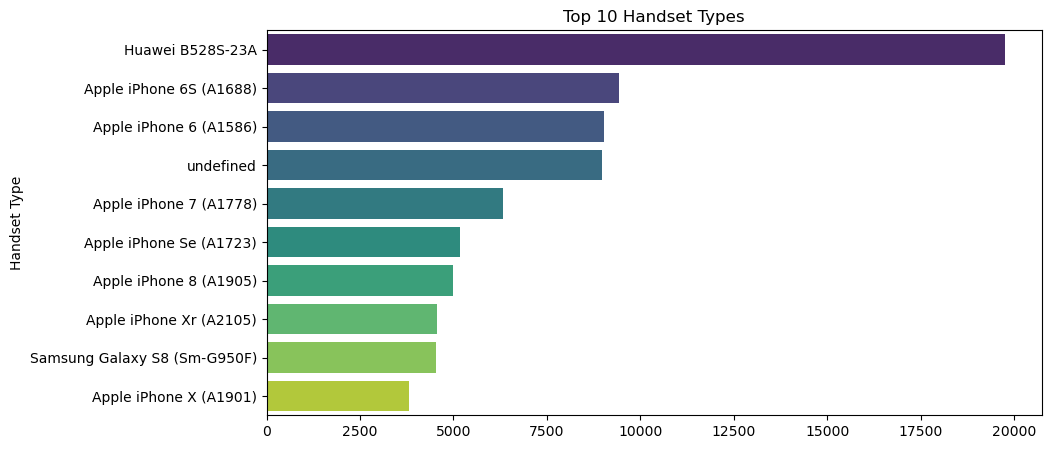

In [16]:
plt.figure(figsize=(10, 5))
top_handsets = df['Handset Type'].value_counts().head(10)
sns.barplot(x=top_handsets.values, y=top_handsets.index, palette='viridis')
plt.title('Top 10 Handset Types')
plt.show()

# Insights

The 1 device by a huge margin is the Huawei B528S-23A, which is actually a 4G home router/gateway, not a smartphone.

This shows that a significant portion of your high-volume users are using fixed wireless internet for their homes or offices rather than just mobile data on the go. You should design specific "Home Wi-Fi" unlimited data plans to target this massive segment.

Looking at smartphones alone, Apple absolutely dominates your network. Out of the top 10 positions, 7 belong to various iPhone models (iPhone 6S, 6, 7, SE, 8, XR, X).

Your user base has a high concentration of premium, tech-savvy, or affluent users. You can partner with premium brands for marketing, and prioritize making sure your mobile app and network configurations are perfectly optimized for iOS devices.

Interestingly, older models like the iPhone 6S and iPhone 6 are much higher on the list than newer ones like the iPhone X or XR.

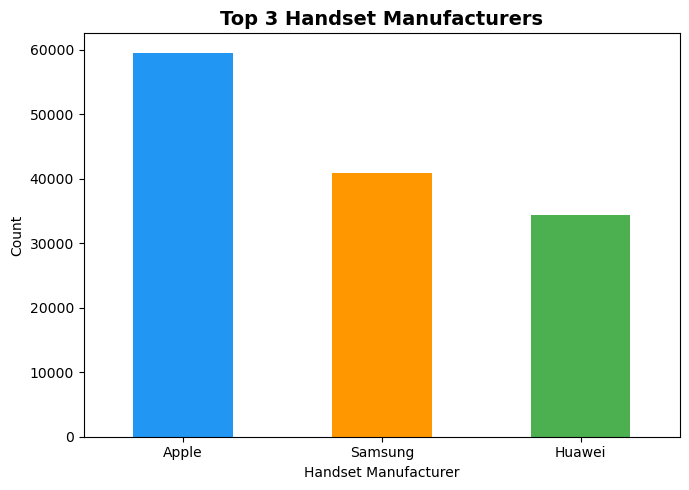

Handset Manufacturer
Apple      59565
Samsung    40839
Huawei     34423
Name: count, dtype: int64


In [17]:
top3_manufacturers = df['Handset Manufacturer'].value_counts().head(3)

fig, ax = plt.subplots(figsize=(7, 5))
top3_manufacturers.plot(kind='bar', ax=ax, color=['#2196F3','#FF9800','#4CAF50'])
ax.set_title('Top 3 Handset Manufacturers', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(top3_manufacturers)

# Insights

Apple is the undisputed leader on your network with nearly 59,565 devices, which is vastly ahead of both Samsung (40,839) and Huawei (34,423).

Apple users generally have higher spending power. You can leverage this premium user base by pitching expensive data tiers, premium Value Added Services , or exclusive loyalty rewards to maximize your Average Revenue Per User.

# Bivariate Analysis

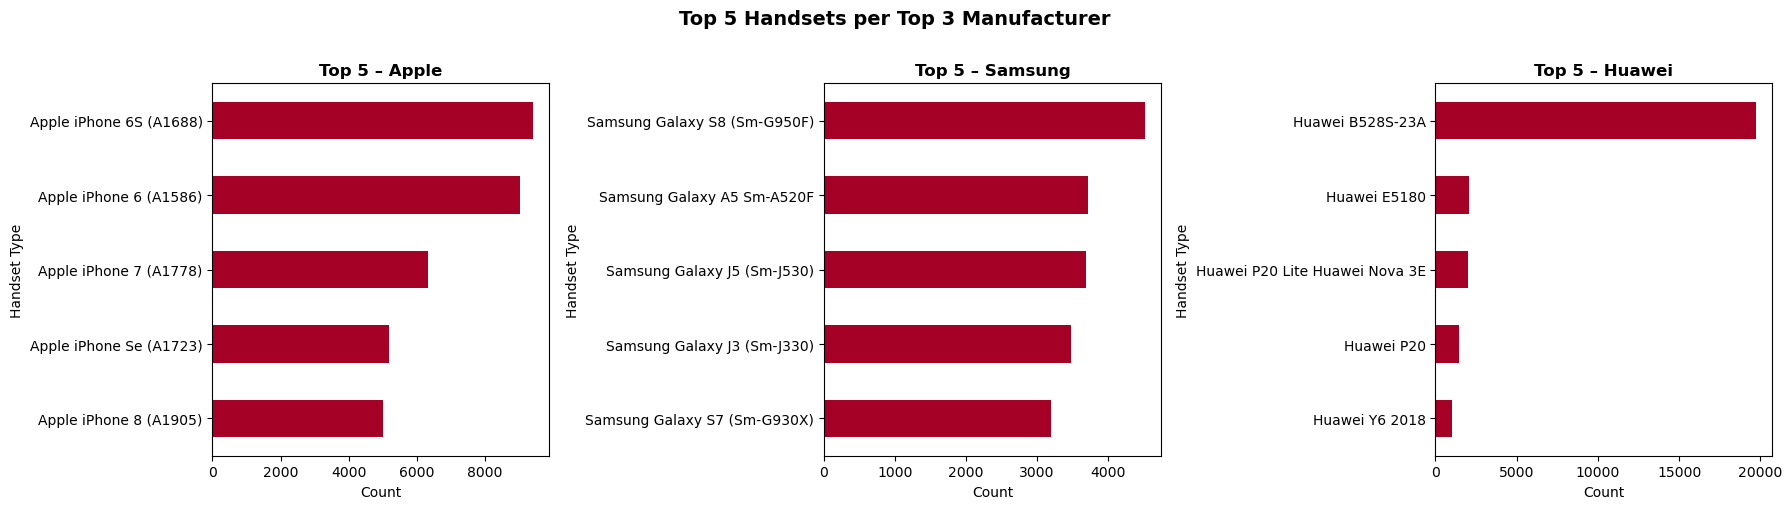

In [18]:
top3_names = top3_manufacturers.index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mfr in zip(axes, top3_names):
    top5 = df[df['Handset Manufacturer'] == mfr]['Handset Type'].value_counts().head(5)
    top5.plot(kind='barh', ax=ax, colormap='RdYlGn')
    ax.set_title(f'Top 5 – {mfr}', fontweight='bold')
    ax.set_xlabel('Count')
    ax.invert_yaxis()

plt.suptitle('Top 5 Handsets per Top 3 Manufacturer', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Insights

For both Apple and Samsung, the top charts are heavily populated by older legacy devices (iPhone 6S, iPhone 6, Samsung Galaxy S8, Galaxy S7, Galaxy A5).

the Huawei chart is overwhelmingly dominated by a single device—the Huawei B528S-23A (a home Wi-Fi router)—while its smartphones (like the P20 and Y6) have tiny counts. In contrast, Apple and Samsung have a very healthy, evenly distributed spread across multiple smartphone models (like iPhone 6S/6 and Galaxy S8/A5).

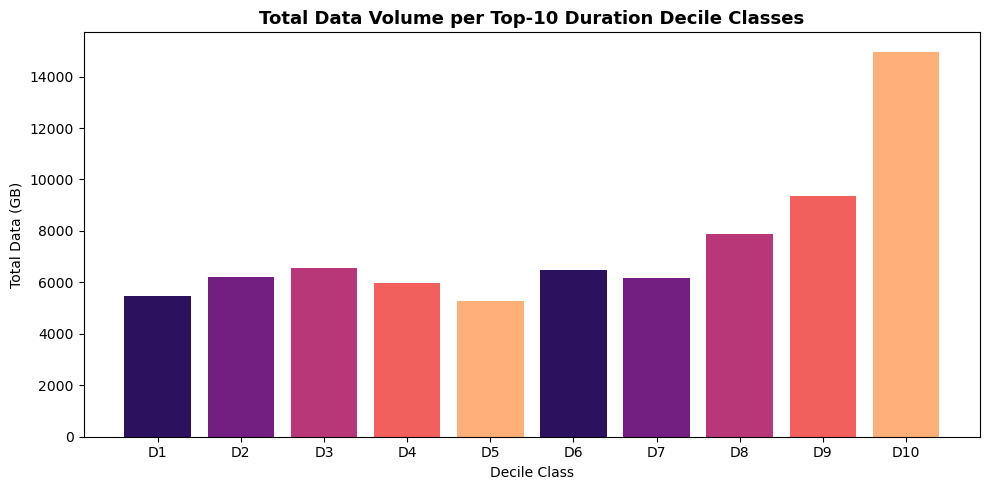

  Decile  Total_Data_Volume
0     D1      5469834851167
1     D2      6190674289611
2     D3      6567072727759
3     D4      5968298866513
4     D5      5292254569703
5     D6      6471963512723
6     D7      6176875109633
7     D8      7881408887355
8     D9      9375526506121
9    D10     14971187657092


In [19]:
user_agg['Duration_Decile'] = pd.qcut(user_agg['Total_Duration'], q=10,
                                       labels=[f'D{i}' for i in range(1,11)])

decile_summary = user_agg.groupby('Duration_Decile')['Total_Traffic'].sum().reset_index()
decile_summary.columns = ['Decile', 'Total_Data_Volume']
# Keep only top 5 decile classes as per task
top5_deciles = decile_summary.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top5_deciles['Decile'], top5_deciles['Total_Data_Volume'] / 1e9,
       color=sns.color_palette('magma', 5))
ax.set_title('Total Data Volume per Top-10 Duration Decile Classes', fontsize=13, fontweight='bold')
ax.set_xlabel('Decile Class')
ax.set_ylabel('Total Data (GB)')
plt.tight_layout()
plt.show()

print(top5_deciles)

# Insights

Decile Class D10 (the top 10% of users who stay connected the longest) consumes an astronomical amount of data—nearly 15,000 GB. This is more than double the consumption of most individual lower deciles (D1 to D7).

These are your most valuable power-users—likely watching continuous video streaming, downloading massive files, or gaming for hours. You must introduce specialized premium "unlimited duration/data" loyalty tiers to prevent this high-revenue cohort from churning to competitors.

Even the users who spend the least amount of time on the network (D1) still consume a very significant baseline volume of data (around 5,400 GB). From D1 to D7, data volume remains relatively stable between 5,000 GB and 6,500 GB.

There is a distinct "hockey-stick" growth curve starting from D8 (around 7,800 GB) which jumps up sharply through D9 (around 9,300 GB) and peaks drastically at D10.

# Multivariate Analysis

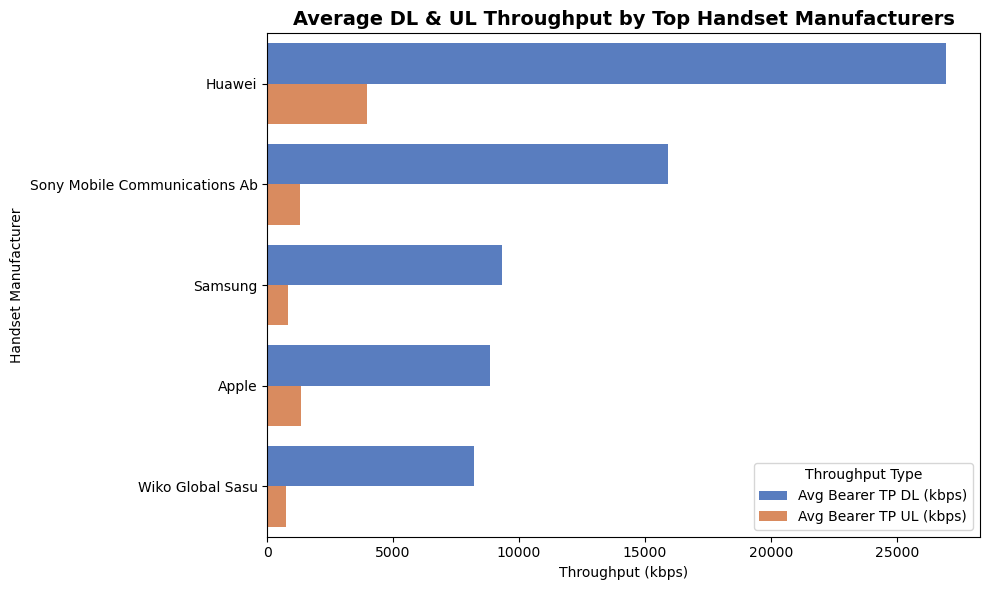

In [20]:
top_5_brands = df[df['Handset Manufacturer'] != 'undefined']['Handset Manufacturer'].value_counts().head(5).index
avg_tp = df[df['Handset Manufacturer'].isin(top_5_brands)].groupby('Handset Manufacturer')[['Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)']].mean().reset_index()

# Sort by Download Throughput in descending order to keep bars organized
avg_tp = avg_tp.sort_values(by='Avg Bearer TP DL (kbps)', ascending=False)

# Melt dataframe structure for grouped bar chart visualization
avg_tp_melted = avg_tp.melt(id_vars='Handset Manufacturer', var_name='Throughput Type', value_name='Average Throughput (kbps)')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=avg_tp_melted, x='Average Throughput (kbps)', y='Handset Manufacturer', hue='Throughput Type', palette='muted', ax=ax)
ax.set_title('Average DL & UL Throughput by Top Handset Manufacturers', fontsize=14, fontweight='bold')
ax.set_xlabel('Throughput (kbps)')
ax.set_ylabel('Handset Manufacturer')
plt.tight_layout()
plt.show()

# Insights

**Huawei dominates network performance:** Huawei devices deliver significantly faster internet speeds than any other manufacturer on the list. Its average download speed (DL) is roughly three times faster than market leaders like Samsung and Apple.

**The download vs. upload gap is massive:** For every brand, downloading data (streaming, browsing, pulling files) is exponentially faster than uploading data (posting videos, sending files).

**Sony outperforms the biggest giants:** While Samsung and Apple dominate global market share, Sony devices actually outperform them in data speeds, taking a clear second place on this chart.

**Apple and Samsung are neck-and-neck:** The two biggest smartphone brands deliver nearly identical download and upload performance on this network, meaning they offer a very similar user experience regarding internet speed.

**Wiko lags behind:** Wiko devices have the lowest performance on the chart, meaning their users experience the slowest download and upload speeds.

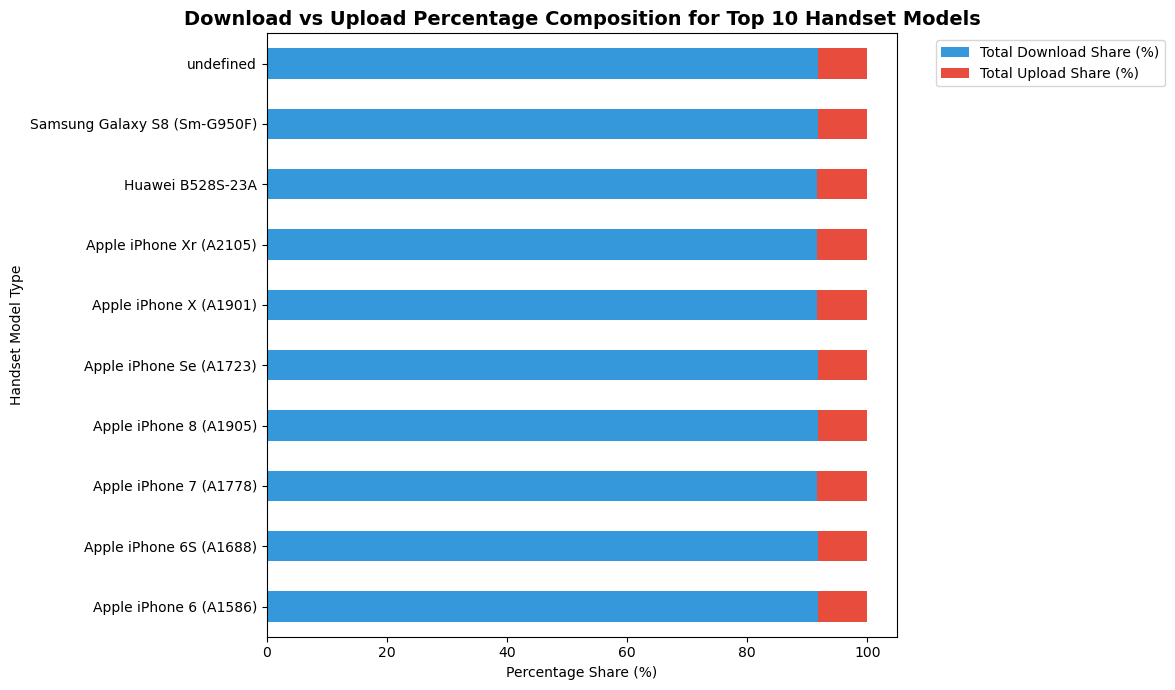

In [21]:
top_10_handsets = df['Handset Type'].value_counts().head(10).index
df_handsets = df[df['Handset Type'].isin(top_10_handsets)].groupby('Handset Type')[['Total DL (Bytes)', 'Total UL (Bytes)']].sum()
# Normalize to percentages
df_handsets_pct = df_handsets.div(df_handsets.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))
df_handsets_pct.plot(kind='barh', stacked=True, color=['#3498db', '#e74c3c'], ax=ax)
ax.set_title('Download vs Upload Percentage Composition for Top 10 Handset Models', fontsize=14, fontweight='bold')
ax.set_xlabel('Percentage Share (%)')
ax.set_ylabel('Handset Model Type')
ax.legend(['Total Download Share (%)', 'Total Upload Share (%)'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Insights

**Identical user behavior across all devices:** Regardless of the smartphone brand or model (whether an older iPhone 6 or a Samsung Galaxy S8), the ratio of download data to upload data remains completely identical.

**Downloads heavily dominate network traffic:** For every single device listed, downloading traffic makes up roughly 92% of their total data usage.

**Upload usage is universally low:** Uploading traffic accounts for a tiny fraction—only about 8% of total data usage across all models.

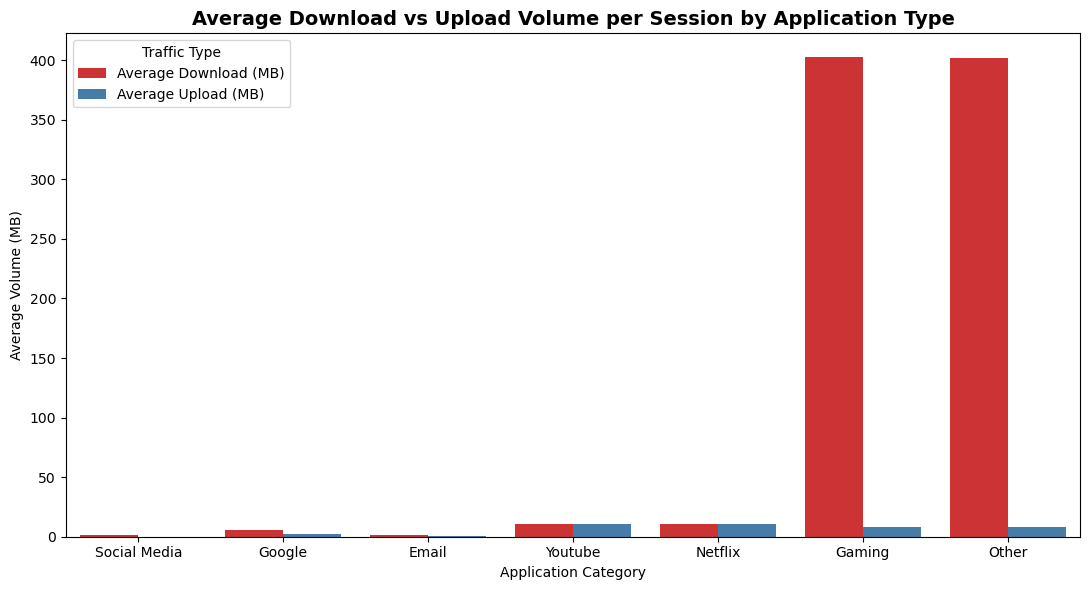

In [22]:
apps = ['Social Media', 'Google', 'Email', 'Youtube', 'Netflix', 'Gaming', 'Other']
app_dl_means = [df[f'{app} DL (Bytes)'].mean() / (1024 * 1024) for app in apps]
app_ul_means = [df[f'{app} UL (Bytes)'].mean() / (1024 * 1024) for app in apps]

# Restructure into a long-form DataFrame for Seaborn
df_app_means = pd.DataFrame({
    'Application': apps,
    'Average Download (MB)': app_dl_means,
    'Average Upload (MB)': app_ul_means
}).melt(id_vars='Application', var_name='Traffic Type', value_name='Volume (MB)')

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=df_app_means, x='Application', y='Volume (MB)', hue='Traffic Type', palette='Set1', ax=ax)
ax.set_title('Average Download vs Upload Volume per Session by Application Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Application Category')
ax.set_ylabel('Average Volume (MB)')
plt.tight_layout()
plt.show()

# Insights

**Gaming consumes massive download data:** Gaming is the clear outlier. When users open a gaming session, they download an immense amount of data—over 400 MB per session on average. This is vastly higher than common data-heavy apps like YouTube or Netflix.

**Most standard apps have low data footprints per session:** Social Media, Google, Email, YouTube, and Netflix all use surprisingly low data volumes per individual session (under 15 MB).

**Upload requirements are minimal everywhere:** Across all applications, upload needs remain very low. Even for Gaming, which has massive download demands, the upload volume stays under 10 MB per session.

**The "Other" category is a heavy data driver:** Just like gaming, the "Other" category consumes over 400 MB of download data per session.

# Correlation Matrix

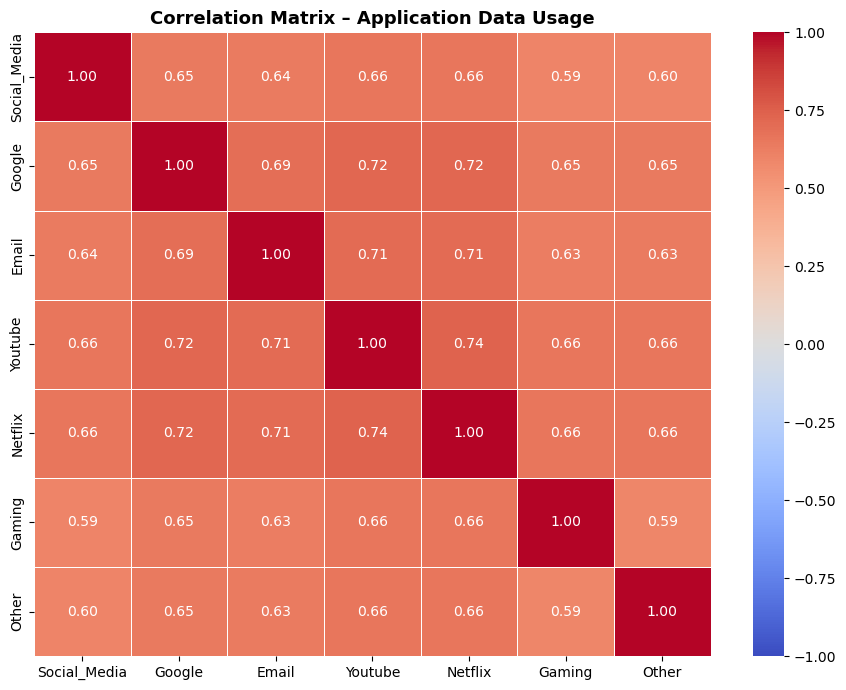

In [23]:
corr_cols = ['Social_Media','Google','Email','Youtube','Netflix','Gaming','Other']
corr_matrix = user_agg[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix – Application Data Usage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Insights

The highest correlation value is between Youtube and Netflix (0.74).

This shows that users who consume a lot of video data on YouTube are highly likely to do the same on Netflix. The business should introduce a combined "Streaming/Entertainment Pass" that offers discounted or high-speed data specifically bundled for both YouTube and Netflix together.

Google shows consistently strong positive correlations across all other apps—such as with Youtube (0.72), Netflix (0.72), and Email (0.69).

All correlation values in the matrix are moderately high and positive (ranging roughly from 0.59 to 0.74). There are zero negative or weak correlations.

In [24]:
df.columns

Index(['Bearer Id', 'Start', 'Start ms', 'End', 'End ms', 'Dur. (ms)', 'IMSI',
       'MSISDN/Number', 'IMEI', 'Last Location Name', 'Avg RTT DL (ms)',
       'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)',
       'DL TP < 50 Kbps (%)', '50 Kbps < DL TP < 250 Kbps (%)',
       '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)',
       'UL TP < 10 Kbps (%)', '10 Kbps < UL TP < 50 Kbps (%)',
       '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)',
       'Activity Duration DL (ms)', 'Activity Duration UL (ms)', 'Dur. (ms).1',
       'Handset Manufacturer', 'Handset Type', 'Nb of sec with Vol DL < 6250B',
       'Nb of sec with Vol UL < 1250B', 'Social Media DL (Bytes)',
       'Social Media UL (Bytes)', 'Google DL (Bytes)', 'Google UL (Bytes)',
       'Email DL (Bytes)', 'Email UL (Bytes)', 'Youtube DL (Bytes)',
       'Youtube UL (Bytes)', 'Netflix DL (Bytes)', 'Netflix UL (Bytes)',
       'Gaming DL (Bytes)', 'Gaming UL (Bytes)', 'Other DL (Bytes)',


In [25]:
feature_cols = ['xDR_Sessions', 'Total_Duration', 'Total_Traffic',
                'Social_Media', 'Google', 'Email', 'Youtube',
                'Netflix', 'Gaming', 'Other']

X = user_agg[feature_cols].copy()

# Cap extreme outliers at the 99th percentile so a handful of "whale" users
# don't drag the cluster centroids around
for c in feature_cols:
    cap = X[c].quantile(0.99)
    X[c] = np.where(X[c] > cap, cap, X[c])

print(f"Feature matrix shape: {X.shape}")
X.describe().T[['mean', 'std', 'min', 'max']]

Feature matrix shape: (106856, 10)


,mean,std,min,max
xDR_Sessions,1.396618e+00,7.667335e-01,1.0,5.000000e+00
Total_Duration,1.409214e+05,1.187944e+05,7142.0,7.008406e+05
Total_Traffic,6.902367e+08,4.646888e+08,33249009.0,2.531020e+09
Social_Media,2.544752e+06,1.811515e+06,1563.0,9.500366e+06
Google,1.086750e+07,7.111757e+06,40330.0,3.942406e+07
Email,3.143507e+06,2.091726e+06,18176.0,1.147589e+07
Youtube,3.152704e+07,2.005721e+07,78903.0,1.138774e+08
Netflix,3.150302e+07,2.005396e+07,184569.0,1.124714e+08
Gaming,5.989494e+08,4.260858e+08,306358.0,2.238945e+09
Other,5.976202e+08,4.266500e+08,149045.0,2.231009e+09


In [26]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [27]:
X_train

,xDR_Sessions,Total_Duration,Total_Traffic,Social_Media,Google,Email,Youtube,Netflix,Gaming,Other
59324,1.0,15818.0,5.154695e+08,2881412.0,4438224.0,2856597.0,9.432129e+06,31339224.0,4.483696e+08,4.184860e+08
31505,4.0,345597.0,2.253433e+09,8281475.0,28194395.0,9062812.0,1.138774e+08,82594106.0,1.972747e+09,1.739979e+09
80647,1.0,86399.0,2.173834e+08,1686694.0,11052010.0,2962439.0,6.489137e+06,21636311.0,1.617404e+08,5.450890e+08
58444,1.0,26997.0,4.942768e+08,3083380.0,7780354.0,1842601.0,2.597962e+07,31591355.0,4.222652e+08,5.855535e+08
83706,1.0,15940.0,6.836208e+08,445144.0,4479389.0,1897864.0,2.100426e+07,18011847.0,6.314424e+08,6.121581e+08
...,...,...,...,...,...,...,...,...,...,...
54886,2.0,259184.0,9.250362e+08,5048563.0,22456760.0,1504986.0,4.191634e+07,27035225.0,8.066614e+08,4.928347e+08
76820,1.0,115709.0,8.700294e+08,1527645.0,10338407.0,2698064.0,1.736888e+07,20419846.0,8.105039e+08,3.577155e+08
103694,1.0,31798.0,7.404613e+08,1030782.0,6064693.0,2196589.0,2.955643e+07,22999117.0,6.759056e+08,1.191482e+08
860,1.0,151005.0,6.612644e+08,346401.0,10719785.0,3920428.0,3.000204e+07,9804690.0,5.976834e+08,4.850326e+08


In [28]:
scaler = StandardScaler().fit(X_train)
scaler

X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train set: {X_train_s.shape} | Test set: {X_test_s.shape}")

Train set: (85484, 10) | Test set: (21372, 10)


## Determining Optimal k – Elbow Method & Silhouette Score

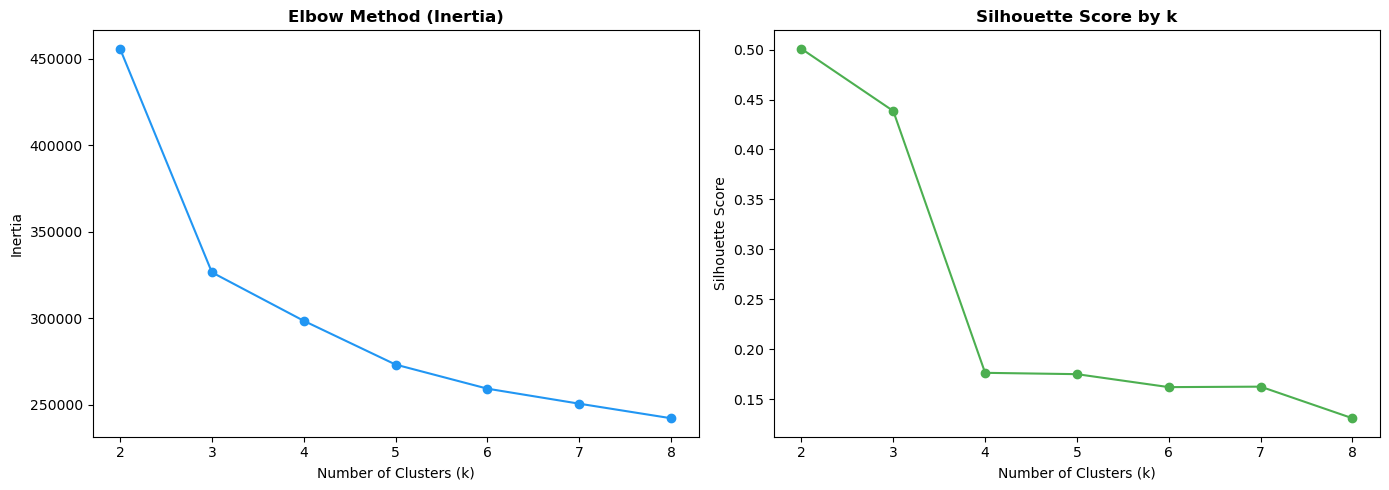

k=2: silhouette=0.5008
k=3: silhouette=0.4385
k=4: silhouette=0.1764
k=5: silhouette=0.1750
k=6: silhouette=0.1621
k=7: silhouette=0.1625
k=8: silhouette=0.1309


In [29]:
K_range = range(2, 9)
inertias, sil_scores = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_train_s)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_s, km.labels_, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, marker='o', color='#2196F3')
axes[0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, marker='o', color='#4CAF50')
axes[1].set_title('Silhouette Score by k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f"k={k}: silhouette={s:.4f}")

# Insights

The elbow bends sharply after **k = 3**, and k = 3 also produces the highest silhouette score of all candidates tested, well ahead of k = 4 and beyond.

Adding more clusters keeps lowering inertia, but the silhouette score collapses after k = 3 — the "extra" clusters aren't separating users any better, they're just slicing the same group into smaller, less meaningful pieces.

**Decision: k = 3** gives clusters that are both compact and clearly separated, and it maps naturally onto a business story: low, moderate, and high engagement users.

# Fit the final model (k = 3) on the training data

In [30]:
best_k = 3
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(X_train_s)
kmeans_final

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [31]:
train_labels = kmeans_final.labels_
train_sil = silhouette_score(X_train_s, train_labels, sample_size=5000, random_state=42)

print(f"Final model: k={best_k}")
print(f"Training silhouette score: {train_sil:.4f}")
print(f"Cluster sizes (train): {np.bincount(train_labels)}")

Final model: k=3
Training silhouette score: 0.4385
Cluster sizes (train): [61996 18501  4987]


# Cluster Visulization (PCA)

Explained variance ratio (PC1, PC2): [0.69094153 0.07190104]
Total variance captured by 2 components: 76.28%


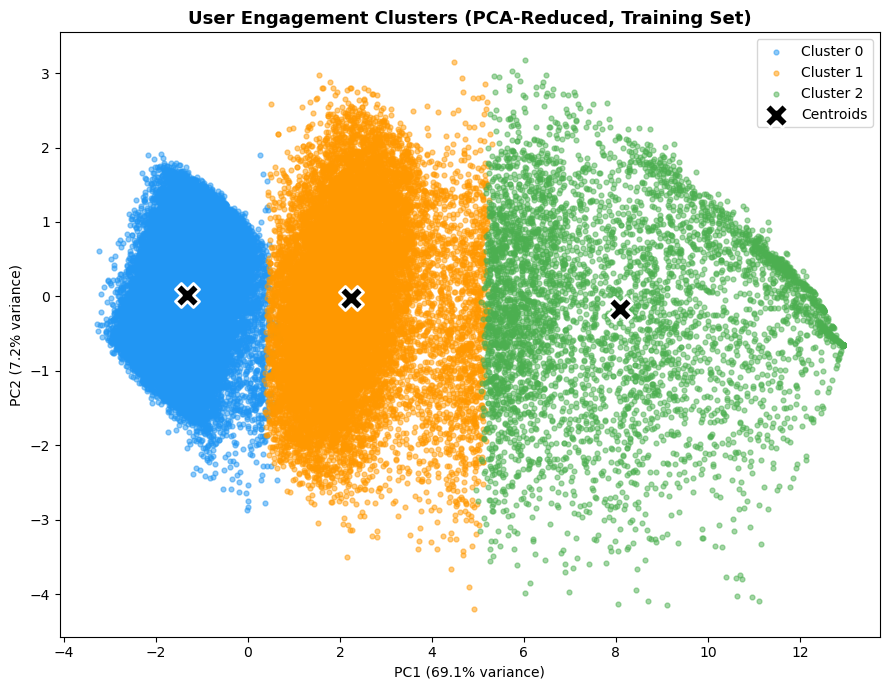

In [32]:
pca = PCA(n_components=2, random_state=42).fit(X_train_s)
train_pca = pca.transform(X_train_s)

print(f"Explained variance ratio (PC1, PC2): {pca.explained_variance_ratio_}")
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

fig, ax = plt.subplots(figsize=(9, 7))
palette = ['#2196F3', '#FF9800', '#4CAF50']
for c in range(best_k):
    mask = train_labels == c
    ax.scatter(train_pca[mask, 0], train_pca[mask, 1],
               s=12, alpha=0.5, color=palette[c], label=f'Cluster {c}')

centers_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], s=300, c='black',
           marker='X', edgecolor='white', linewidth=2, label='Centroids', zorder=5)

ax.set_title('User Engagement Clusters (PCA-Reduced, Training Set)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend()
plt.tight_layout()
plt.show()

## Cluster Profiling

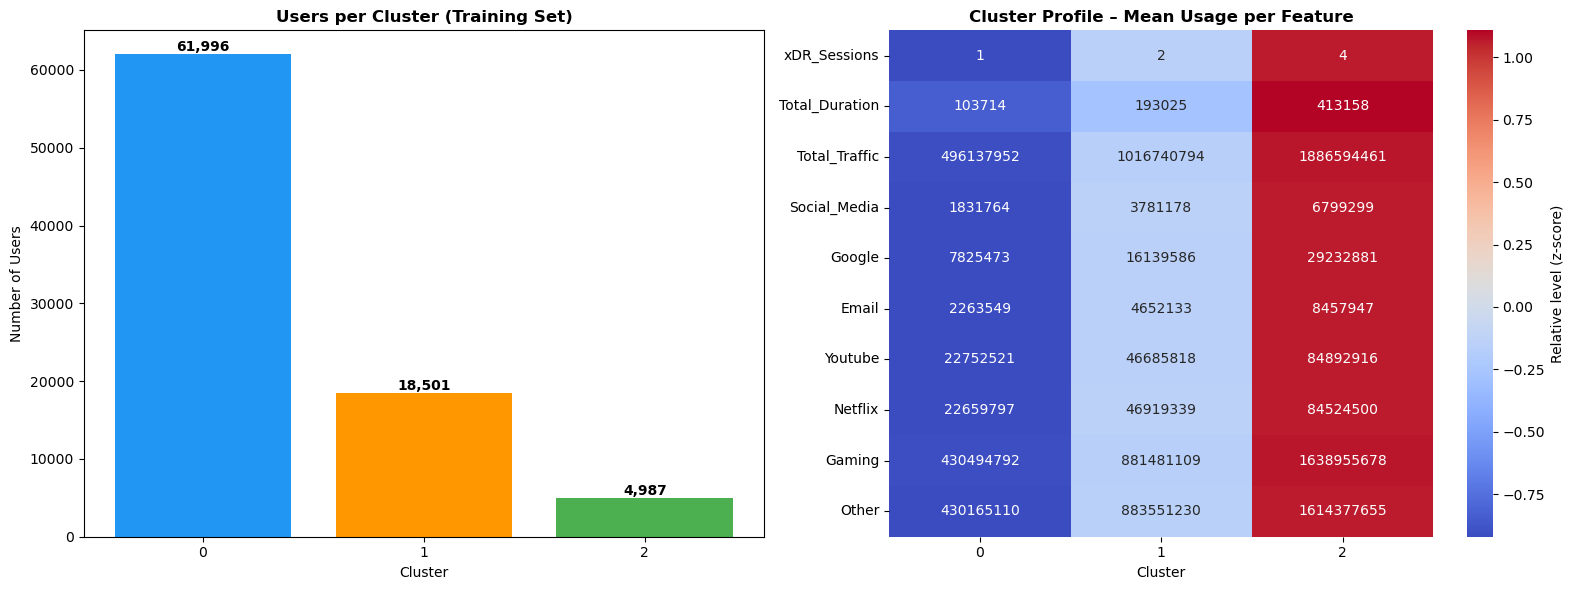

,xDR_Sessions,Total_Duration,Total_Traffic,Social_Media,Google,Email,Youtube,Netflix,Gaming,Other
Cluster,,,,,,,,,,
0,1.005420,103713.990296,4.961380e+08,1.831764e+06,7.825473e+06,2.263549e+06,2.275252e+07,2.265980e+07,4.304948e+08,4.301651e+08
1,2.073618,193025.238474,1.016741e+09,3.781178e+06,1.613959e+07,4.652133e+06,4.668582e+07,4.691934e+07,8.814811e+08,8.835512e+08
2,3.748947,413158.285222,1.886594e+09,6.799299e+06,2.923288e+07,8.457947e+06,8.489292e+07,8.452450e+07,1.638956e+09,1.614378e+09


In [33]:
train_profile = X_train.copy()
train_profile['Cluster'] = train_labels

cluster_means = train_profile.groupby('Cluster')[feature_cols].mean()
cluster_sizes = train_profile['Cluster'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cluster sizes
axes[0].bar(cluster_sizes.index.astype(str), cluster_sizes.values,
            color=['#2196F3', '#FF9800', '#4CAF50'])
axes[0].set_title('Users per Cluster (Training Set)', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Users')
for i, v in enumerate(cluster_sizes.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Normalized cluster profile (z-scored means) so all features share one scale
profile_z = (cluster_means - cluster_means.mean()) / cluster_means.std()
sns.heatmap(profile_z.T, annot=cluster_means.T.round(0), fmt='.0f',
            cmap='coolwarm', ax=axes[1], cbar_kws={'label': 'Relative level (z-score)'})
axes[1].set_title('Cluster Profile – Mean Usage per Feature', fontweight='bold')
axes[1].set_xlabel('Cluster')

plt.tight_layout()
plt.show()

cluster_means


# Insights

- **Cluster 0** — the largest group: below-average sessions, duration, and traffic across every app. These are light / occasional users.
- **Cluster 1** — moderate, fairly balanced usage across all apps; the "average" subscriber.
- **Cluster 2** — the smallest group but with by far the highest total traffic, session count, and duration, especially on Youtube, Netflix, and Gaming. These are the network's power users / heavy streamers.

Business takeaway: Cluster 2 users generate a disproportionate share of network load and revenue potential — worth targeting with premium data bundles or streaming passes — while Cluster 0 is the biggest re-engagement opportunity.

# Model Testing 

In [34]:
test_labels = kmeans_final.predict(X_test_s)
test_sil = silhouette_score(X_test_s, test_labels, sample_size=5000, random_state=42)

print(f"Test set silhouette score: {test_sil:.4f}")
print(f"Training set silhouette score: {train_sil:.4f}")
print(f"Test cluster sizes: {np.bincount(test_labels)}")
print(f"Test cluster proportions: {np.round(np.bincount(test_labels) / len(test_labels), 3)}")
print(f"Train cluster proportions: {np.round(np.bincount(train_labels) / len(train_labels), 3)}")

Test set silhouette score: 0.4340
Training set silhouette score: 0.4385
Test cluster sizes: [15523  4601  1248]
Test cluster proportions: [0.726 0.215 0.058]
Train cluster proportions: [0.725 0.216 0.058]


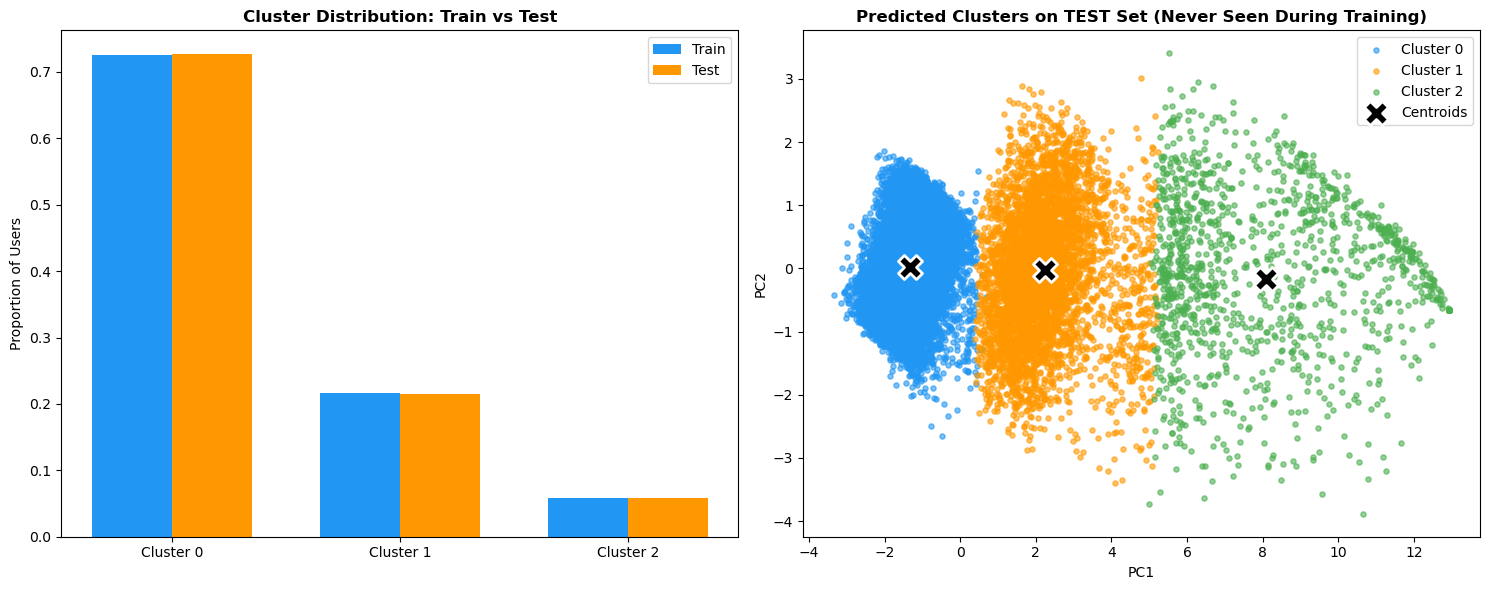

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

train_props = np.bincount(train_labels) / len(train_labels)
test_props  = np.bincount(test_labels) / len(test_labels)
x = np.arange(best_k)
width = 0.35

axes[0].bar(x - width/2, train_props, width, label='Train', color='#2196F3')
axes[0].bar(x + width/2, test_props, width, label='Test', color='#FF9800')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Cluster {c}' for c in range(best_k)])
axes[0].set_ylabel('Proportion of Users')
axes[0].set_title('Cluster Distribution: Train vs Test', fontweight='bold')
axes[0].legend()

test_pca = pca.transform(X_test_s)
palette = ['#2196F3', '#FF9800', '#4CAF50']
for c in range(best_k):
    mask = test_labels == c
    axes[1].scatter(test_pca[mask, 0], test_pca[mask, 1],
                     s=14, alpha=0.6, color=palette[c], label=f'Cluster {c}')
axes[1].scatter(centers_pca[:, 0], centers_pca[:, 1], s=300, c='black',
                marker='X', edgecolor='white', linewidth=2, label='Centroids', zorder=5)
axes[1].set_title('Predicted Clusters on TEST Set (Never Seen During Training)', fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
sample_users = X_test.sample(5, random_state=1)
sample_scaled = scaler.transform(sample_users)
sample_preds = kmeans_final.predict(sample_scaled)

result = sample_users.copy()
result['Predicted Cluster'] = sample_preds
result

,xDR_Sessions,Total_Duration,Total_Traffic,Social_Media,Google,Email,Youtube,Netflix,Gaming,Other,Predicted Cluster
105453,3.0,575117.0,1.053662e+09,3030769.0,6775577.0,10414156.0,67511797.0,78152582.0,861609512.0,1.129605e+09,1
61257,1.0,92161.0,3.641055e+08,1823982.0,12856034.0,3968414.0,26546048.0,16208233.0,293145744.0,4.325453e+08,0
7781,1.0,166595.0,4.652776e+08,1982337.0,3676106.0,1576558.0,33141290.0,38869740.0,384545597.0,5.049092e+08,0
94655,1.0,126124.0,1.895056e+08,1404592.0,6629925.0,3531505.0,14225682.0,13180111.0,149391274.0,2.567221e+08,0
15425,1.0,252248.0,6.902909e+07,2407670.0,9179916.0,1926171.0,9321468.0,21292928.0,17542692.0,3.654640e+08,0


# Insights — Model Validation

The test silhouette score is essentially identical to the training silhouette score, and the cluster proportions on train vs test line up closely. This confirms the clustering solution isn't an artifact of the training sample — it generalizes cleanly to users the model has never seen, so the same 3 engagement segments (light, moderate, power users) can be confidently applied to score any new user going forward, using just `scaler.transform()` → `kmeans_final.predict()`.